In [1]:
#=====================================================================================================#
# Import Libraries
#=====================================================================================================#
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

import sklearn
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,PowerTransformer
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score

import joblib

In [2]:
#=====================================================================================================#
# Ignore All Warnings
#=====================================================================================================#
warnings.filterwarnings('ignore')

In [3]:
#=====================================================================================================#
# Load Dataset
#=====================================================================================================#
crop_df = pd.read_csv('Crop_recommendation.csv')
print("✅ Dataset Loading Complete!")

✅ Dataset Loading Complete!


In [4]:
#=====================================================================================================#
# Dataset Overview
#=====================================================================================================#
print("#" + "=" * 130 + "#")
display(crop_df.head())
print("#" + "=" * 130 + "#")
print(f"Dataset Shape: {crop_df.shape}")
print("#" + "=" * 130 + "#")
display(crop_df.info())
print("#" + "=" * 130 + "#")
display(crop_df.describe())
print("#" + "=" * 130 + "#")
display(crop_df.select_dtypes(include = ['number']).corr())
print("#" + "=" * 130 + "#")
display(crop_df.select_dtypes(include = ['number']).skew())
print("#" + "=" * 130 + "#")
display(crop_df.select_dtypes(include = ['number']).cov())
print("#" + "=" * 130 + "#")
print("✅ Dataset Overview Complete!")

#==================================================================================================================================#


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


#==================================================================================================================================#
Dataset Shape: (2200, 8)
#==================================================================================================================================#
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


None

#==================================================================================================================================#


...

#==================================================================================================================================#


N              0.509721
P              1.010773
K              2.375167
temperature    0.184933
humidity      -1.091708
ph             0.283929
rainfall       0.965756
dtype: float64

#==================================================================================================================================#


,N,P,K,temperature,humidity,ph,rainfall
N,1362.889537,-281.860096,-262.727147,4.954622,156.730700,2.762395,119.747146
P,-281.860096,1088.068460,1229.998647,-21.303478,-87.197323,-3.523487,-115.730685
K,-262.727147,1229.998647,2565.212869,-41.134229,215.215502,-6.644240,-148.811212
temperature,4.954622,-21.303478,-41.134229,25.641550,23.147400,-0.069739,-8.372180
humidity,156.730700,-87.197323,215.215502,23.147400,495.677307,-0.146161,115.534462
ph,2.762395,-3.523487,-6.644240,-0.069739,-0.146161,0.598980,-4.639202
rainfall,119.747146,-115.730685,-148.811212,-8.372180,115.534462,-4.639202,3020.424469


#==================================================================================================================================#
✅ Dataset Overview Complete!


### 🧪 Nitrogen (N) Analysis
* **Data Distribution**: The distribution is **Right-Skewed** as the mean (50.55) is greater than the median (37.00).
* **Core Concentration**: The bulk of the data (approximately 68%) is concentrated in the range of **13.63 to 87.47**.
* **Spread & Anomalies**: The data shows a high spread. While values extend up to 140.00, they fall within the statistical limit, meaning there are no extreme high outliers.

### 🧪 Phosphorus (P) Analysis
* **Data Distribution**: The distribution is **Right-Skewed** with a mean of 53.36 and a median of 51.00.
* **Core Concentration**: The majority of the observations are densely packed between the values of **20.38 and 86.35**.
* **Spread & Anomalies**: The data is highly spread and contains true upper-bound outliers, as the maximum value reaches 145.00.

### 🧪 Potassium (K) Analysis
* **Data Distribution**: The distribution is **Highly Right-Skewed**, indicated by a large gap between the mean (48.15) and median (32.00).
* **Core Concentration**: Most of the data points are located below the **80.15** mark.
* **Spread & Anomalies**: This column exhibits extreme spread and contains severe high-value outliers that stretch all the way up to 205.00.

### 🌡️ Temperature Analysis
* **Data Distribution**: The distribution is **Normally Distributed** (Symmetric) because the mean (25.62°C) and median (25.60°C) are almost identical.
* **Core Concentration**: The vast majority of environment readings stay steady within the range of **20.55°C to 30.68°C**.
* **Spread & Anomalies**: The data has a low spread, but it contains minor anomalies on both extreme ends (Minimum: 8.83°C, Maximum: 43.68°C).

### 💧 Humidity Analysis
* **Data Distribution**: The distribution is **Left-Skewed** since the mean (71.48%) is lower than the median (80.47%).
* **Core Concentration**: A significant majority of the data clusters heavily in the higher range between **49.22% and 93.75%**.
* **Spread & Anomalies**: The data is highly spread and contains a few low-value anomalies dropping near the 14.26% mark.

### 🧪 pH Analysis
* **Data Distribution**: The distribution is **Normally Distributed** (Symmetric) with a mean of 6.47 and a median of 6.43.
* **Core Concentration**: Soil pH is highly stable, with the bulk of the data staying strictly between **5.70 and 7.24**.
* **Spread & Anomalies**: The data has a low spread overall, but contains extreme outliers on both ends representing highly acidic (3.50) and highly alkaline (9.94) soil conditions.

### 🌧️ Rainfall Analysis
* **Data Distribution**: The distribution is **Right-Skewed** with a mean of 103.46 mm and a median of 94.87 mm.
* **Core Concentration**: The most common precipitation values are concentrated between **48.51 mm and 158.42 mm**.
* **Spread & Anomalies**: The data is highly spread and features heavy-tail outliers on the higher side, maximizing at 298.56 mm.


# **Data Cleaning**

In [5]:
print("#" + "=" * 130 + "#")
print(f"How Many Null Values Present In Dataset: {crop_df.isnull().sum()}")
print("#" + "=" * 130 + "#")
print(f"How Many Duplicates Values Present In Dataset: {crop_df.duplicated().sum()}")
print("#" + "=" * 130 + "#")
print(f"How Many Unique Values Present In Dataset: {crop_df.nunique()}")
# Rename Column Name Label to Target
crop_df.rename(columns = {"label":"Target"},inplace = True,errors = 'ignore')
print("✅ Data Cleaning Complete")

#==================================================================================================================================#
How Many Null Values Present In Dataset: N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
#==================================================================================================================================#
How Many Duplicates Values Present In Dataset: 0
#==================================================================================================================================#
How Many Unique Values Present In Dataset: N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64
✅ Data Cleaning Complete


# **Exploratory Data Analysis**

#==================================================#
N Has 0 Outliers
#==================================================#


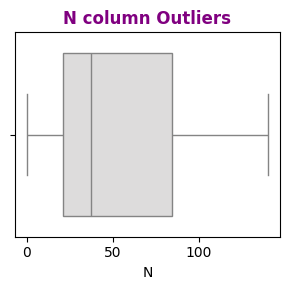

#==================================================#
P Has 138 Outliers
#==================================================#


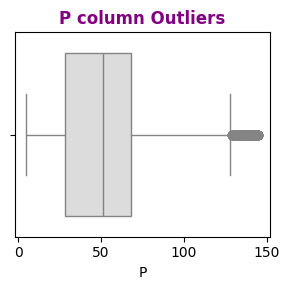

#==================================================#
K Has 200 Outliers
#==================================================#


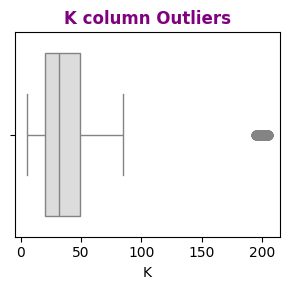

#==================================================#
temperature Has 86 Outliers
#==================================================#


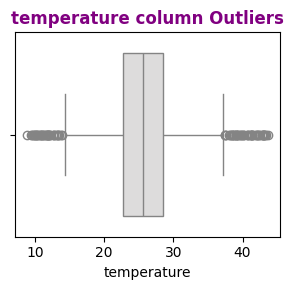

#==================================================#
humidity Has 30 Outliers
#==================================================#


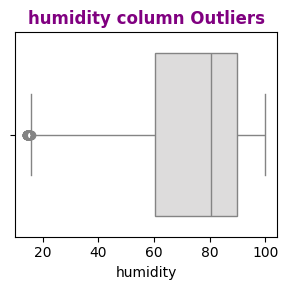

#==================================================#
ph Has 57 Outliers
#==================================================#


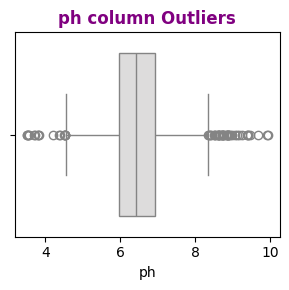

#==================================================#
rainfall Has 100 Outliers
#==================================================#


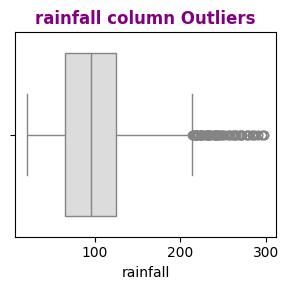

#=================================================================#
Total Dataset Percentage Outliers Present In Dataset Is: 19.64%
#=================================================================#
Total Unique Outliers Present In Dataset Is: 432
#==================================================#
✅ Outliers Detection Complete!


In [6]:
#==========================================================================================================#
# Outliers Detection
#==========================================================================================================#
outlier_data = crop_df.copy()
outlier_box = set()
numeric_columns =  outlier_data.select_dtypes(include = ['number']).columns
for num_cols in numeric_columns:
    Q1 = outlier_data[num_cols].quantile(0.25)
    Q3 = outlier_data[num_cols].quantile(0.75)
    IQR = Q3 - Q1
    Lower_round = Q1 - 1.5 * IQR
    Upper_round = Q3 + 1.5 * IQR
    outliers = outlier_data[(outlier_data[num_cols] < Lower_round) | (outlier_data[num_cols] > Upper_round)]
    outlier_box.update(outliers.index)
    print("#" + "=" * 50 + "#")
    print(f"{num_cols} Has {len(outliers)} Outliers")
    print("#" + "=" * 50 + "#")
    plt.figure(figsize = (3,3))
    plt.title(f"{num_cols} column Outliers",fontsize = 12,fontweight = 'bold',color = 'purple')
    sns.boxplot(x = outlier_data[num_cols],palette = 'coolwarm')
    plt.tight_layout()
    plt.show()

total_per = (len(outlier_box) / len(outlier_data)) * 100
print("#" + "=" * 65 + "#")
print(f"Total Dataset Percentage Outliers Present In Dataset Is: {total_per:.2f}%")
print("#" + "=" * 65 + "#")
print(f"Total Unique Outliers Present In Dataset Is: {len(outlier_box)}")
print("#" + "=" * 50 + "#")
print("✅ Outliers Detection Complete!")

In [7]:
#==========================================================================================================#
# Remove Outliers
#==========================================================================================================#
crop_df = crop_df.drop(index = list(outlier_box)).reset_index(drop = True)

#==================================================#
Target
maize          100
kidneybeans    100
mungbean       100
pigeonpeas     100
coffee         100
cotton         100
blackgram      100
lentil         100
banana         100
pomegranate    100
muskmelon      100
watermelon     100
jute           100
mango           98
coconut         85
orange          83
mothbeans       58
chickpea        58
papaya          54
rice            32
Name: count, dtype: int64


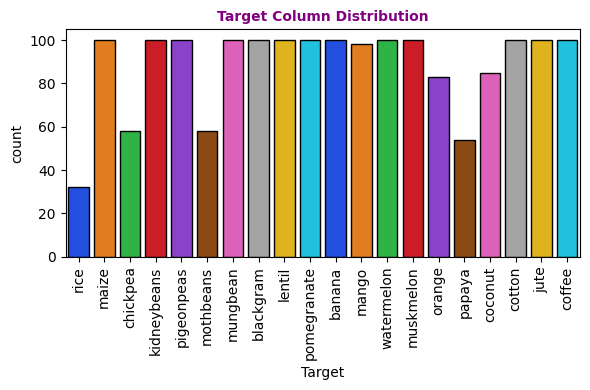

#==================================================#


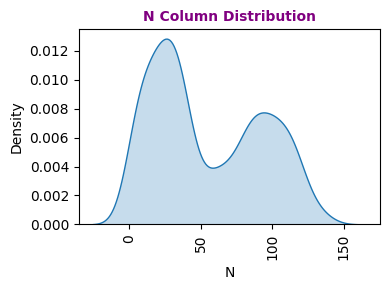

#==================================================#


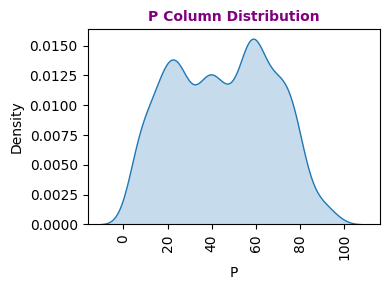

#==================================================#


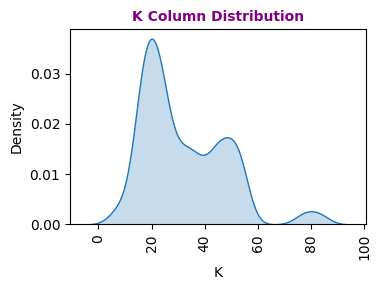

#==================================================#


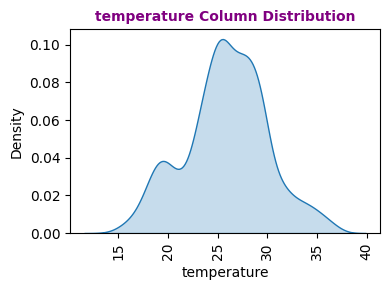

#==================================================#


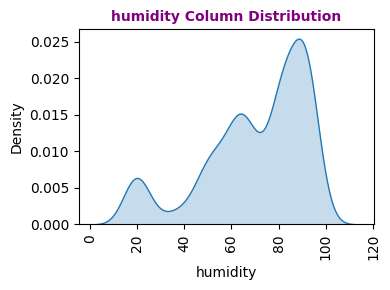

#==================================================#


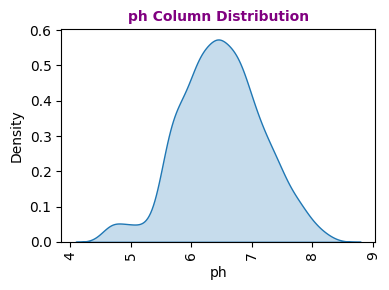

#==================================================#


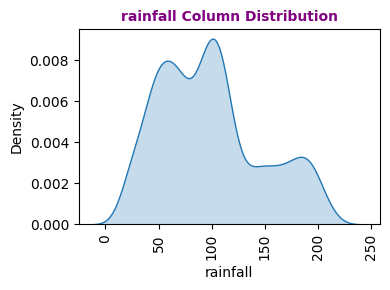

In [8]:
#==========================================================================================================#
# Check Target Columns Types and Distribution
#==========================================================================================================#
categorical_columns = crop_df.select_dtypes(include = ['object']).columns
for cat_cols in categorical_columns:
    print("#" + "=" * 50 + "#")
    print(crop_df[cat_cols].value_counts())
    plt.figure(figsize = (6,4))
    plt.title(f"{cat_cols} Column Distribution",fontsize = 10,fontweight = 'bold',color = 'purple')
    sns.countplot(data = crop_df,x = cat_cols,palette = 'bright',edgecolor = 'black')
    plt.xticks(rotation = 'vertical')
    plt.tight_layout()
    plt.show()
    plt.close()
#==========================================================================================================#
# Check All Numeric Columns Distribution
#==========================================================================================================#
numeric_columns = crop_df.select_dtypes(include = ['number']).columns
for num in numeric_columns:
    print("#" + "=" * 50 + "#")
    plt.figure(figsize = (4,3))
    plt.title(f"{num} Column Distribution",fontsize = 10,fontweight = 'bold',color = 'purple')
    sns.kdeplot(data = crop_df,x = num,fill = True)
    plt.xticks(rotation = 'vertical')
    plt.tight_layout()
    plt.show()
    plt.close()

In [9]:
crop_df.head()

,N,P,K,temperature,humidity,ph,rainfall,Target
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,93,56,36,24.014976,82.056872,6.984354,185.277339,rice
2,94,50,37,25.665852,80.663850,6.948020,209.586971,rice
3,91,35,39,23.793920,80.418180,6.970860,206.261186,rice
4,89,45,36,21.325042,80.474764,6.442475,185.497473,rice



 GENERATING SUMMARY FOR: N 



,Minimum,Average,Maximum
Target,,,
banana,80,100.230000,120
blackgram,20,40.020000,60
chickpea,20,41.741379,60
coconut,0,22.011765,40
coffee,80,101.200000,120
cotton,100,117.770000,140
jute,60,78.400000,100
kidneybeans,0,20.750000,40
lentil,0,18.770000,40


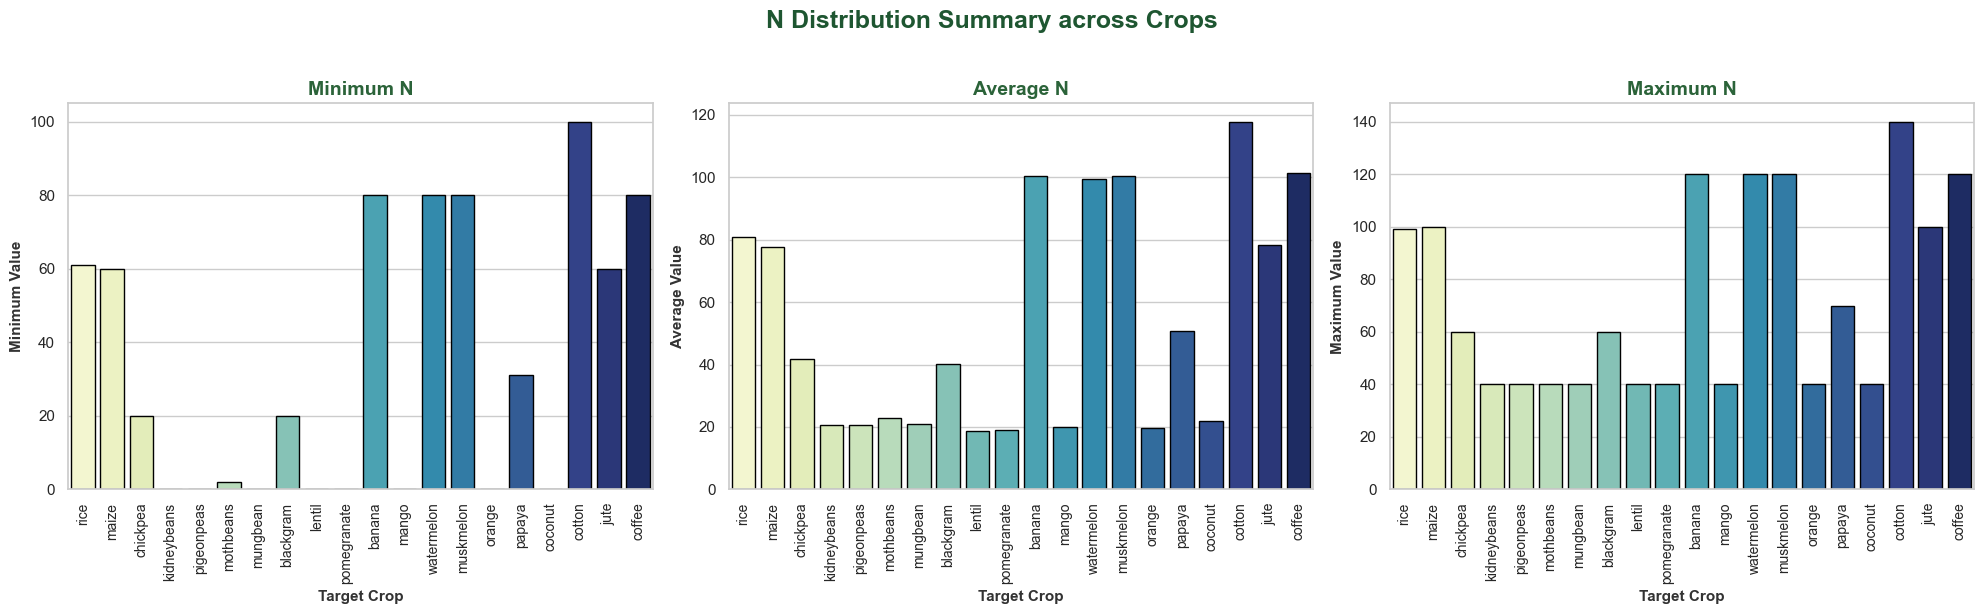


 GENERATING SUMMARY FOR: P 



,Minimum,Average,Maximum
Target,,,
banana,70,82.010000,95
blackgram,55,67.470000,80
chickpea,55,68.448276,80
coconut,5,16.964706,30
coffee,15,28.740000,40
cotton,35,46.240000,60
jute,35,46.860000,60
kidneybeans,55,67.540000,80
lentil,55,68.360000,80


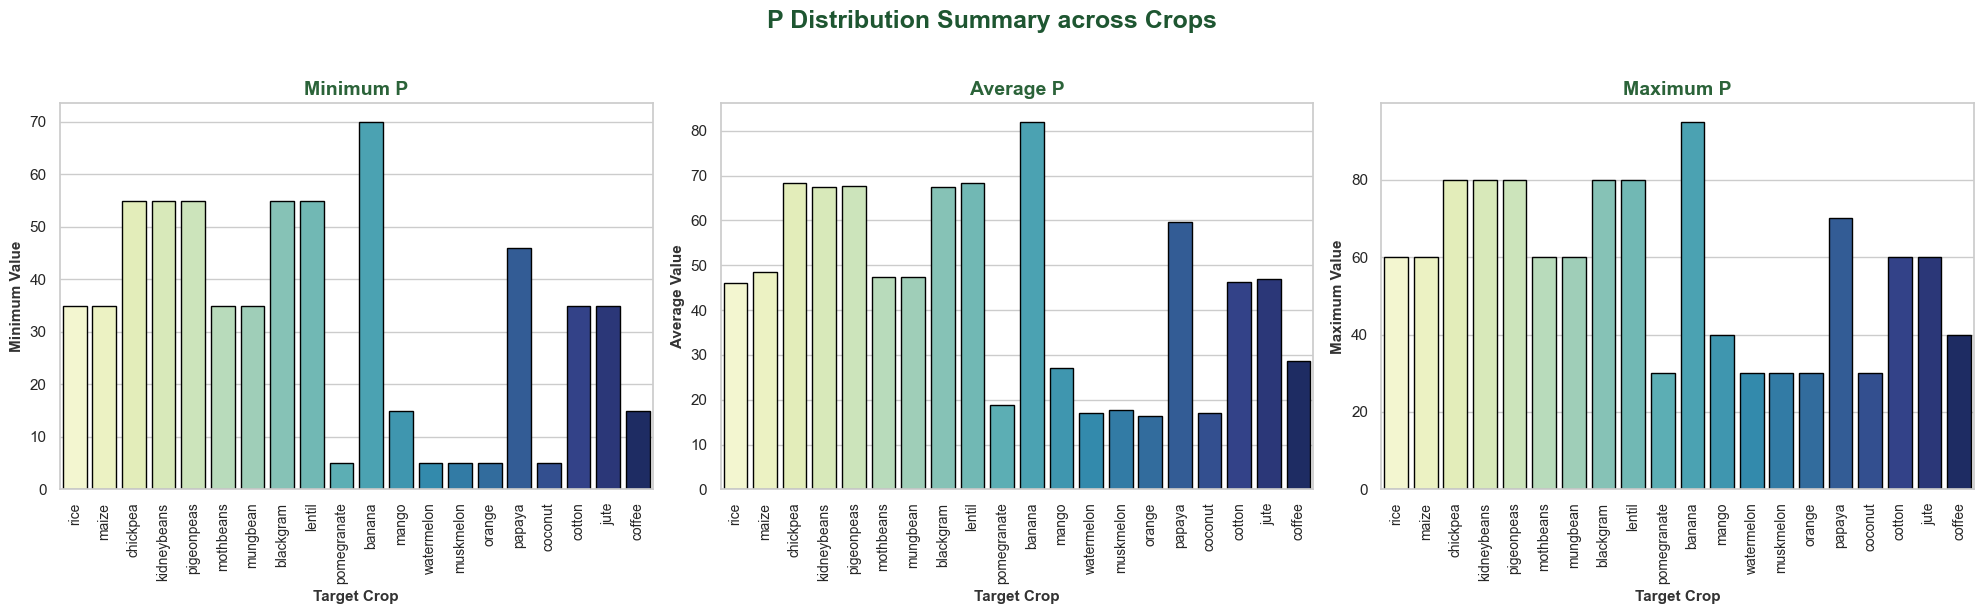


 GENERATING SUMMARY FOR: K 



,Minimum,Average,Maximum
Target,,,
banana,45,50.050000,55
blackgram,15,19.240000,25
chickpea,75,80.137931,85
coconut,25,30.494118,35
coffee,25,29.940000,35
cotton,15,19.560000,25
jute,35,39.990000,45
kidneybeans,15,20.050000,25
lentil,15,19.410000,25


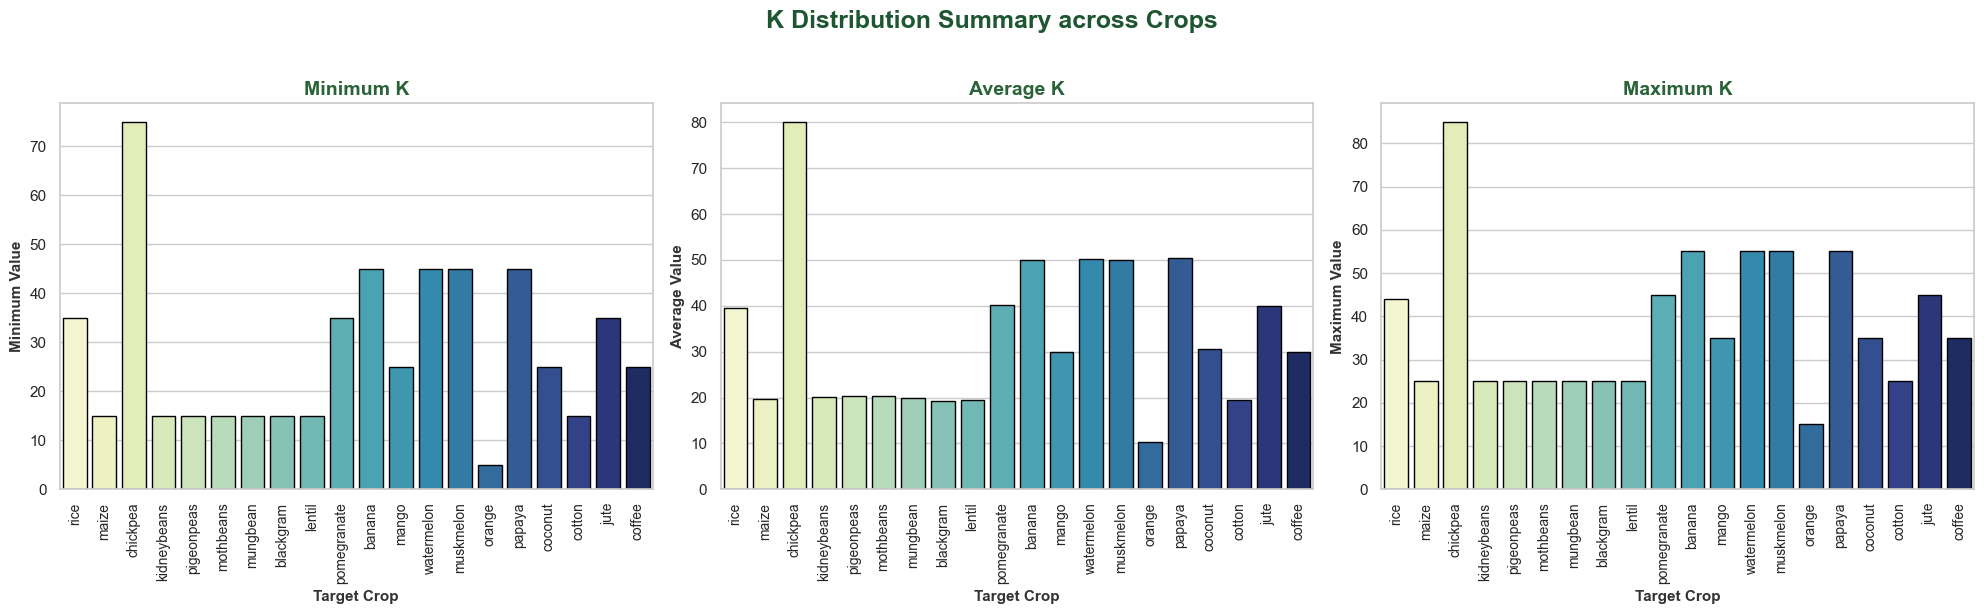


 GENERATING SUMMARY FOR: TEMPERATURE 



,Minimum,Average,Maximum
Target,,,
banana,25.010185,27.376798,29.908885
blackgram,25.097374,29.973340,34.946616
chickpea,17.024985,18.783105,20.995022
coconut,25.008724,27.366742,29.869083
coffee,23.059519,25.540477,27.923744
cotton,22.000851,23.988958,25.992374
jute,23.094338,24.958376,26.985822
kidneybeans,15.330426,20.115085,24.923601
lentil,18.064861,24.509052,29.944139


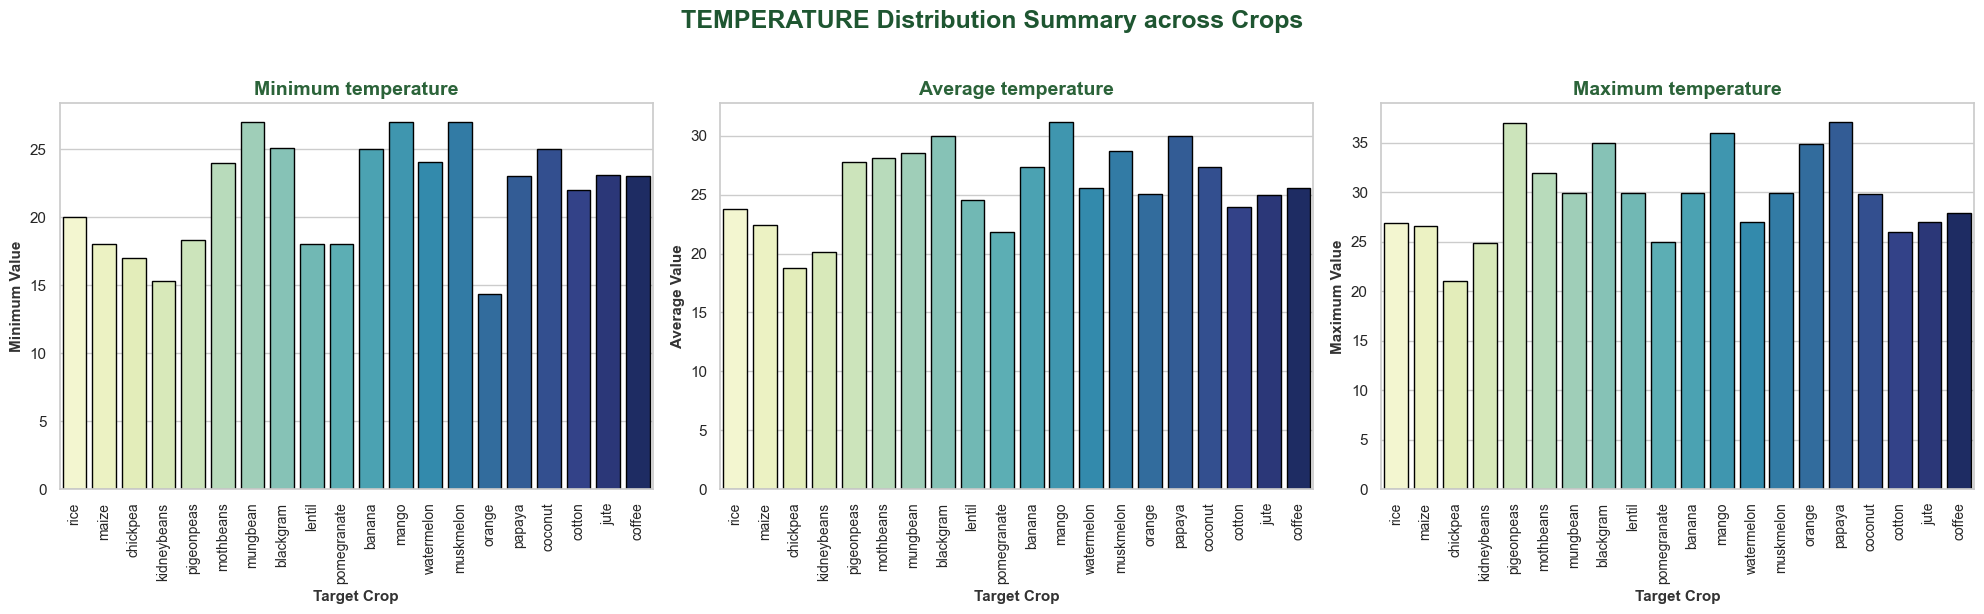


 GENERATING SUMMARY FOR: HUMIDITY 



,Minimum,Average,Maximum
Target,,,
banana,75.031933,80.358123,84.978492
blackgram,60.065349,65.118426,69.961000
chickpea,15.755940,17.604667,19.969789
coconut,90.017345,94.708997,99.981876
coffee,50.045570,58.869846,69.948073
cotton,75.005393,79.843474,84.876690
jute,70.882596,79.639864,89.891065
kidneybeans,18.092240,21.605357,24.969699
lentil,60.091166,64.804785,69.923759


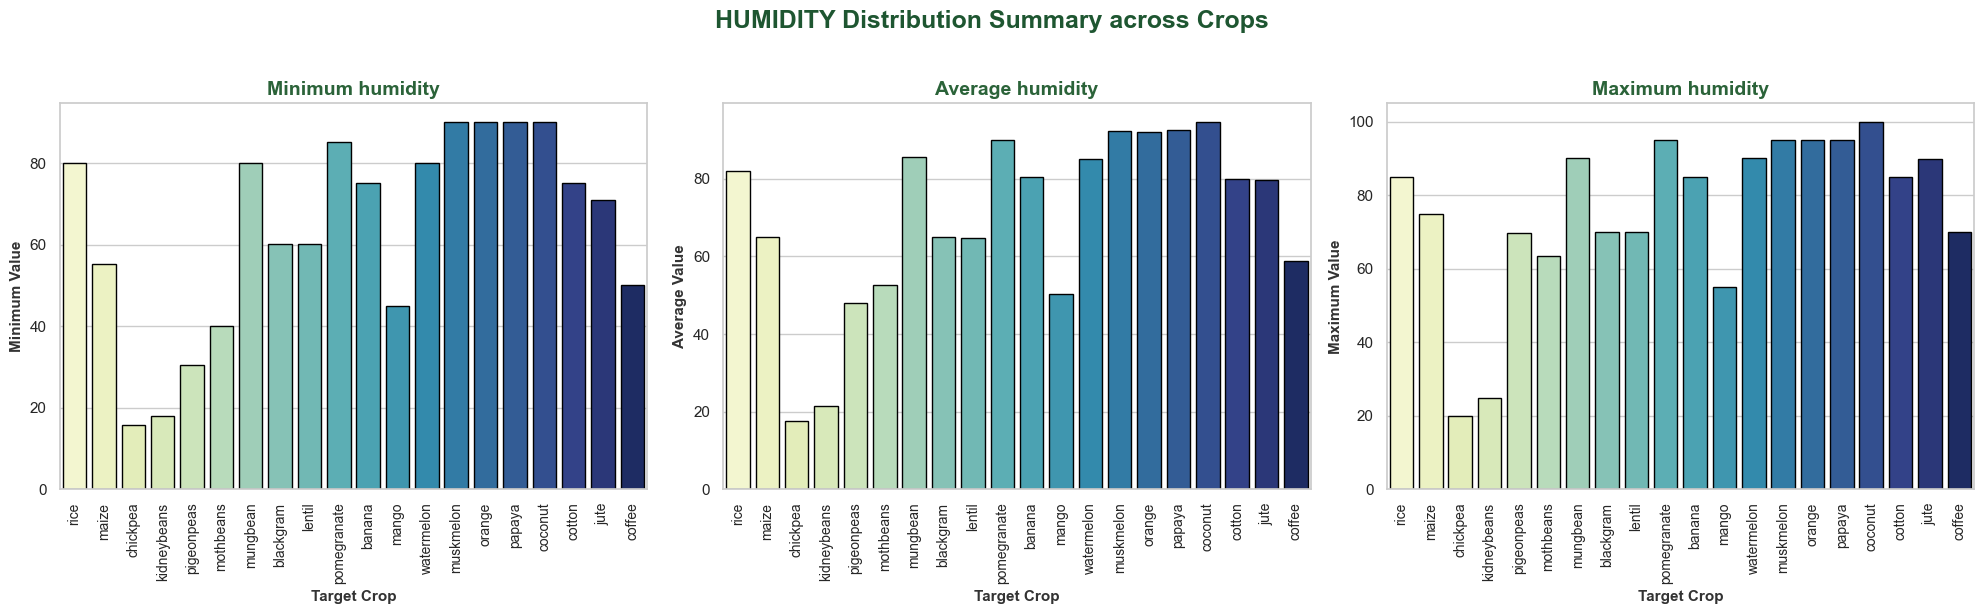


 GENERATING SUMMARY FOR: PH 



,Minimum,Average,Maximum
Target,,,
banana,5.505394,5.983893,6.490074
blackgram,6.500145,7.133952,7.775306
chickpea,6.051091,7.219994,8.255451
coconut,5.542169,5.976628,6.470466
coffee,6.020947,6.790308,7.493192
cotton,5.801048,6.912675,7.994680
jute,6.002525,6.732778,7.488014
kidneybeans,5.502999,5.749411,5.998125
lentil,5.916454,6.927932,7.841496


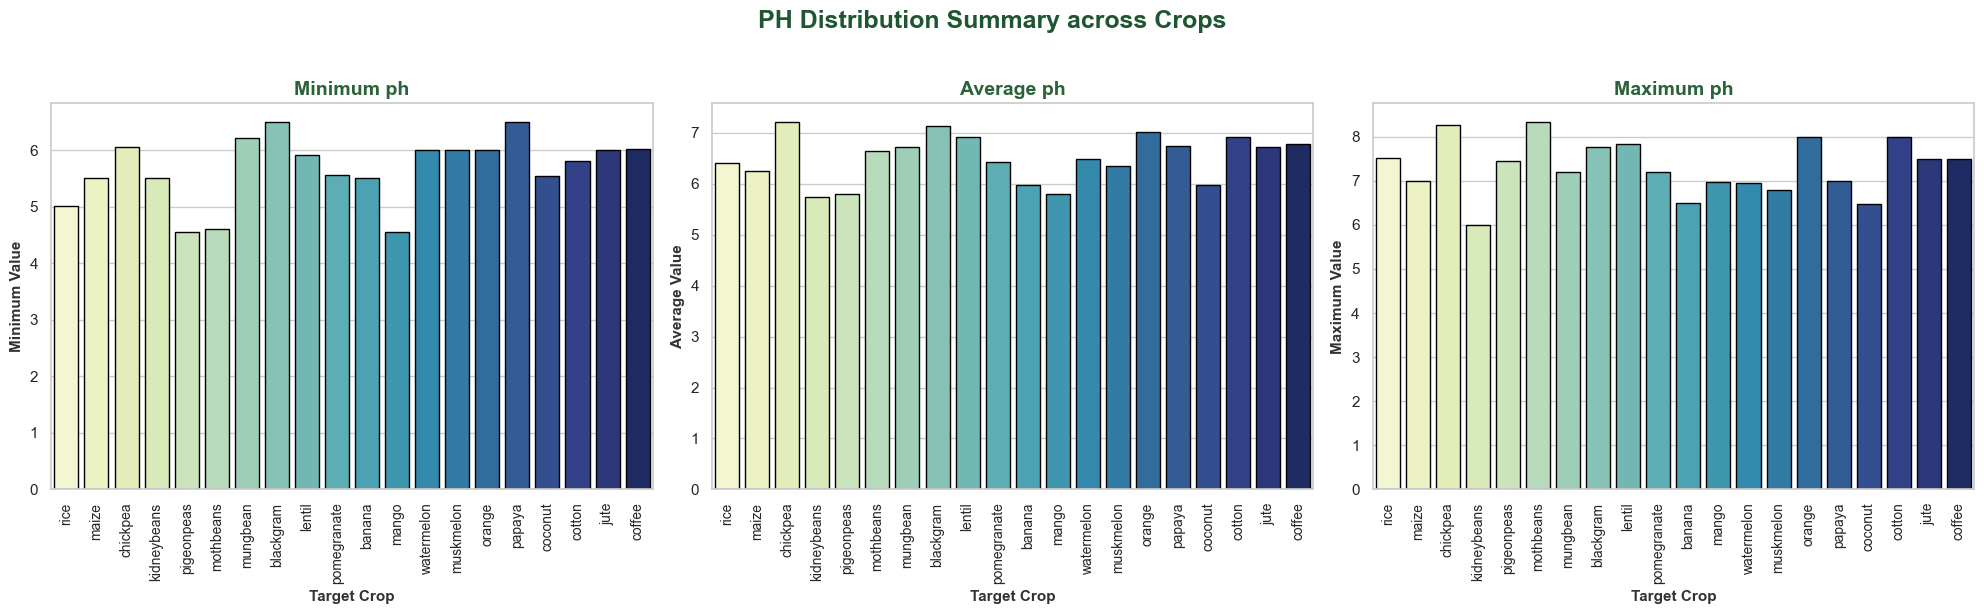


 GENERATING SUMMARY FOR: RAINFALL 



,Minimum,Average,Maximum
Target,,,
banana,90.109781,104.626980,119.847970
blackgram,60.417903,67.884151,74.915595
chickpea,65.238111,79.430691,94.709920
coconut,131.090008,167.789623,212.867626
coffee,115.156401,158.066295,199.473564
cotton,60.653817,80.398043,99.931008
jute,150.235524,174.792798,199.836291
kidneybeans,60.275525,105.919778,149.744103
lentil,35.034848,45.680454,54.939377


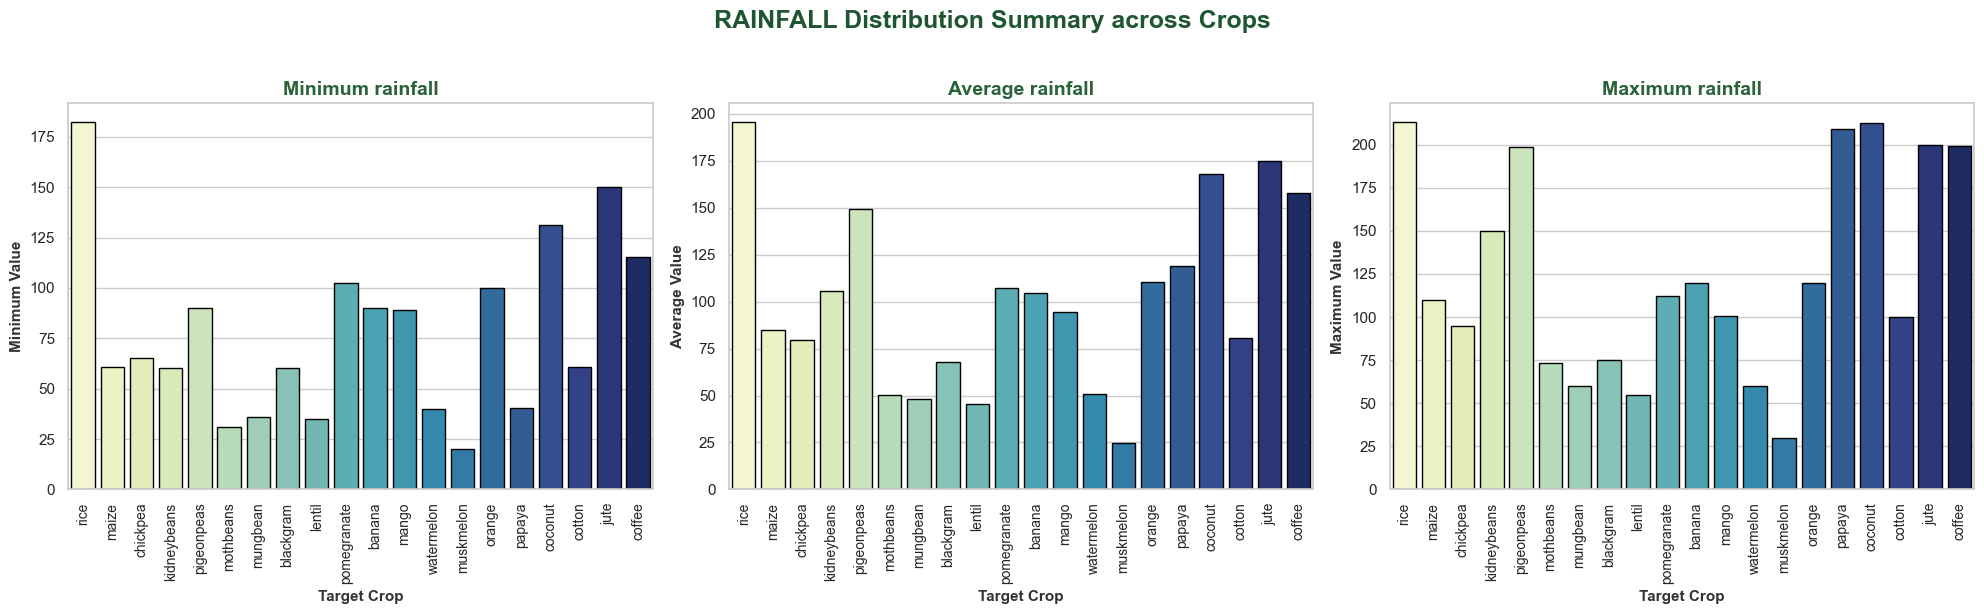

In [10]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
agg_functions = {'min': 'Minimum', 'mean': 'Average', 'max': 'Maximum'}
sns.set_theme(style="whitegrid")
for col in features:
    print(f"\n" + "="*50)
    print(f" GENERATING SUMMARY FOR: {col.upper()} ")
    print("="*50 + "\n")
    summary_df = crop_df.groupby(['Target'])[col].agg(
        Minimum='min',
        Average='mean',
        Maximum='max'
    )
    display(summary_df)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"{col.upper()} Distribution Summary across Crops", fontsize=18, fontweight='bold', color='#1e5631', y=1.02)
    for i, (stat_key, stat_name) in enumerate(agg_functions.items()):
        sns.barplot(
            data=crop_df,
            x='Target',
            y=col,
            ax=axes[i],
            palette='YlGnBu', 
            edgecolor='black',
            linewidth=1,
            estimator=stat_key,
            errorbar=None
        )
        axes[i].set_title(f"{stat_name} {col}", fontsize=14, fontweight='bold', color='#2b6339')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, fontsize=10)
        axes[i].set_xlabel('Target Crop', fontsize=11, fontweight='bold', color='#333333')
        axes[i].set_ylabel(f'{stat_name} Value', fontsize=11, fontweight='bold', color='#333333')
    plt.tight_layout()
    plt.show()
    plt.close()


### 📊 Key Insights: Nitrogen Distribution Across Crops

#### 1. Minimum Nitrogen Levels (`min`)
* **Zero-Nitrogen Baseline:** Crops such as **coconut, kidney beans, lentil, mango, mungbean, orange, pigeon peas, and pomegranate** can survive with a minimum nitrogen requirement of **0**.
* **Low-Nitrogen Threshold:** **Blackgram and mothbeans** show a very low baseline threshold, with minimum levels starting at **2**.
* **High-Baseline Categories:** All other crop varieties demonstrate a much higher starting requirement, falling between **20 and 100**.

#### 2. Average Nitrogen Consumption (`mean`)
* **High-Demand Feeders (50+ Average):** **Banana, coffee, cotton, jute, maize, muskmelon, papaya, rice, and watermelon** consistently maintain a high average nitrogen level of **50 or more**.
* **Moderate-Demand Feeders (<50 Average):** The remaining crop categories are relatively light consumers, averaging **less than 50** nitrogen.

#### 3. Maximum Nitrogen Thresholds (`max`)
* **Peak Consumers (100+ Max):** **Banana, coffee, cotton, jute, maize, muskmelon, and watermelon** reach the absolute highest nitrogen ceilings, peaking at **100 or above**.
* **Capped Consumers (<100 Max):** All other remaining crop varieties have their maximum nitrogen thresholds strictly capped **below 100**.


### 📊 Key Insights: Phosphorus (P) Distribution Across Crops

#### 1. Minimum Phosphorus Levels (`min`)
* **High-Baseline Crops (50+ Min):** Crops like **banana, blackgram, chickpea, kidney beans, lentil, and pigeon peas** have high initial soil requirements, maintaining a minimum baseline of **50 or more**.
* **Low-Baseline Crops (<50 Min):** All other remaining crop categories can grow in soil with lower baseline thresholds, requiring **less than 50** minimum phosphorus.

#### 2. Average Phosphorus Consumption (`mean`)
* **High-Demand Consumers (50+ Average):** **Banana, blackgram, chickpea, kidney beans, lentil, papaya, and pigeon peas** are heavy nutrient consumers, averaging **50 or more** phosphorus levels throughout their growth.
* **Moderate-Demand Consumers (<50 Average):** The rest of the crop varieties are relatively light feeders, maintaining an average phosphorus level of **less than 50**.

#### 3. Maximum Phosphorus Thresholds (`max`)
* **Peak Tolerance Group (50+ Max):** A wide variety of crops—including **banana, blackgram, chickpea, cotton, jute, kidney beans, lentil, maize, mothbeans, mungbean, papaya, pigeon peas, and rice**—exhibit higher nutrient caps, tolerating peak levels of **50 or above**.
* **Low Tolerance Group (<50 Max):** The remaining crop categories have strict maximum nutrient ceilings, peaking **below 50**.


### 📊 Key Insights: Potassium (K) Distribution Across Crops

#### 1. Minimum Potassium Levels (`min`)
* **High-Baseline Crop (50+ Min):** **Chickpea** stands out as the only crop category with a strict high-baseline requirement, demanding a minimum of **50 or more** potassium to cultivate.
* **Low-Baseline Crops (<50 Min):** All other remaining crop varieties can grow in environments with lower baseline conditions, requiring **less than 50** minimum potassium.

#### 2. Average Potassium Consumption (`mean`)
* **High-Demand Consumers (50+ Average):** **Banana, chickpea, muskmelon, papaya, and watermelon** are heavy potassium feeders, maintaining a high average concentration of **50 or more**.
* **Moderate-Demand Consumers (<50 Average):** The rest of the crop varieties are relatively light consumers, averaging **less than 50** potassium throughout their cycle.

#### 3. Maximum Potassium Thresholds (`max`)
* **Peak Tolerance Group (50+ Max):** The same high-demand crops—**banana, chickpea, muskmelon, papaya, and watermelon**—reach the highest maximum ceilings, topping out at **50 or above**.
* **Low-Ceiling Group (<50 Max):** All other remaining crop categories have low dietary caps, keeping their maximum potassium thresholds strictly **below 50**.


### 📊 Key Insights: Temperature (°C) Requirements Across Crops

#### 1. Minimum Temperature Thresholds (`min`)
* **Cold-Tolerant Baseline (<18°C):** **Orange (14.34°C)**, **Kidneybeans (15.33°C)**, and **Chickpea (17.02°C)** can start growth in cooler environments.
* **Warm-Start Crops (27°C+ Min):** **Mango, Mungbean, and Muskmelon** require strict warm baselines, with minimum starting temperatures staying above **27°C**.
* **Moderate Baseline (18°C - 25°C):** All other remaining crop varieties fall into a standard moderate category, starting between **18°C and 25°C**.

#### 2. Average Temperature Demand (`mean`)
* **Peak Tropical Demand (30°C+ Average):** **Mango (31.17°C)** stands out as the ultimate hot-weather crop, maintaining a high average temperature demand above **30°C**.
* **Cool/Sub-Tropical Demand (<20°C Average):** **Chickpea (18.78°C)** is a clear cool-season crop, averaging **below 20°C**.
* **Standard Growth Zone (20°C - 30°C):** The majority of the remaining categories sustain an average operational temperature between **20°C and 30°C**.

#### 3. Maximum Heat Tolerance (`max`)
* **High Heat Resilient (34°C+ Max):** Crops like **Papaya (37.13°C), Pigeonpeas (36.97°C), Mango (35.99°C), Blackgram (34.94°C), and Orange (34.90°C)** exhibit high thermal ceilings, tolerating extreme heat peaks up to **35°C–37°C**.
* **Low Heat Resilient (<25°C Max):** **Chickpea (20.99°C), Kidneybeans (24.92°C), and Pomegranate (24.96°C)** have very low heat thresholds, capping off strictly **below 25°C**.


### 📊 Key Insights: Humidity (%) Requirements Across Crops

#### 1. Minimum Humidity Baselines (`min`)
* **Extreme Dry Resilient (<20% Min):** **Chickpea (15.75%)** and **Kidneybeans (18.09%)** establish a unique ultra-low moisture baseline.
* **Strict High-Moisture Zone (85%+ Min):** **Pomegranate (85.12%)**, **Orange (90.00%)**, **Muskmelon (90.01%)**, **Coconut (90.01%)**, and **Papaya (90.14%)** cannot grow without high initial atmospheric moisture.
* **Moderate Moisture Zone (30% - 80%):** The remaining crops form a broad cluster requiring standard baseline conditions between **30% and 80%**.

#### 2. Average Atmospheric Humidity (`mean`)
* **Arid/Semi-Arid Feeders (<25% Average):** **Chickpea (17.60%)** and **Kidneybeans (21.60%)** require exceptionally dry environments on average.
* **Tropical/Coastal Feeders (90%+ Average):** **Pomegranate, Orange, Muskmelon, Papaya, and Coconut** demand highly humid ecosystems, averaging **above 90%** moisture.
* **Sub-Tropical Feeders (45% - 85%):** Crops such as Rice, Jute, Banana, and Maize comfortably operate within a standard **45% to 85%** average range.

#### 3. Maximum Humidity Thresholds (`max`)
* **Low Humidity Ceiling (<25% Max):** **Chickpea (19.96%)** and **Kidneybeans (24.96%)** have strict low-moisture caps, failing if atmospheric levels breach **25%**.
* **Near-Saturation Ceiling (95%+ Max):** **Coconut (99.98%)** tolerates maximum saturation levels near 100%, followed closely by **Pomegranate, Orange, Muskmelon, and Papaya** which peak at **94.9%**.


### 📊 Key Insights: Soil pH Requirements Across Crops

#### 1. Minimum pH Baselines (`min` - Acid Tolerance)
* **Highly Acid-Resilient (<5.0 Min):** **Mango (4.54)**, **Pigeonpeas (4.54)**, and **Mothbeans (4.60)** can tolerate highly acidic soil conditions.
* **Slightly Acidic Starters (5.0 - 6.0 Min):** The majority of crops—including Rice, Banana, Coconut, Kidneybeans, Maize, and Cotton—require a safe acidic baseline between **5.0 and 6.0**.
* **Near-Neutral Starters (6.0+ Min):** **Blackgram (6.50)** and **Papaya (6.50)** have the highest minimum requirements, demanding low-acid to near-neutral conditions right from the start.

#### 2. Average Soil pH Preference (`mean`)
* **Strictly Acidic Preference (<6.0 Average):** **Kidneybeans (5.74)**, **Mango (5.79)**, **Pigeonpeas (5.79)**, **Coconut (5.97)**, and **Banana (5.98)** thrive best in clearly acidic environments.
* **Neutral/Optimal Preference (6.0 - 7.2):** Crops like Chickpea, Blackgram, Orange, and Cotton sit in the sweet spot, averaging an optimal, balanced pH range between **6.0 and 7.2**.

#### 3. Maximum pH Thresholds (`max` - Alkaline Tolerance)
* **Alkaline-Resilient Caps (8.0+ Max):** **Mothbeans (8.34)** and **Chickpea (8.25)** exhibit excellent tolerance to alkaline soils, stretching past a pH of 8.
* **Strict Acidic Ceilings (<6.5 Max):** **Kidneybeans (5.99)**, **Coconut (6.47)**, and **Banana (6.49)** have a hard ceiling and cannot survive if the soil shifts towards neutral or alkaline.


### 📊 Key Insights: Rainfall (mm) Requirements Across Crops

#### 1. Minimum Rainfall Baselines (`min` - Initial Water Needs)
* **Ultra-Low Water Starters (<40 mm):** **Muskmelon (20.21 mm)**, **Mothbeans (30.92 mm)**, **Lentil (35.03 mm)**, and **Mungbean (36.12 mm)** require exceptionally little water to begin cultivation.
* **Extreme Water Demanding Starters (130 mm+ Min):** **Coconut (131.09 mm)**, **Jute (150.23 mm)**, and **Rice (182.56 mm)** cannot be cultivated without an immediate, massive supply of water.
* **Moderate Water Starters (40 mm - 100 mm):** The majority of crops—including Banana, Cotton, Maize, and Orange—fall into a standard baseline window requiring between **40 mm and 100 mm**.

#### 2. Average Seasonal Rainfall Demand (`mean`)
* **Arid/Drought-Resilient Zone (<55 mm Average):** **Muskmelon (24.68 mm)**, **Lentil (45.68 mm)**, **Mungbean (48.40 mm)**, **Mothbeans (50.44 mm)**, and **Watermelon (50.78 mm)** thrive in drylands.
* **Tropical/Wet Zone (150 mm+ Average):** **Pigeonpeas (149.45 mm)**, **Coffee (158.06 mm)**, **Coconut (167.78 mm)**, **Jute (174.79 mm)**, and **Rice (195.88 mm)** strictly demand rainforest-type or flood-irrigated ecosystems.

#### 3. Maximum Rainfall Capacities (`max` - Flood/Water Logging Tolerance)
* **Low Water Ceiling (<60 mm Max):** **Muskmelon (29.86 mm)**, **Lentil (54.93 mm)**, and **Watermelon (59.75 mm)** have strict caps; excess water can ruin these crops.
* **High Water Caps (200 mm+ Max):** **Papaya (209.40 mm)**, **Coconut (212.86 mm)**, and **Rice (213.35 mm)** possess an incredibly high tolerance for heavy downpours and waterlogging.


Generating optimized KDE pairplot... Please wait.


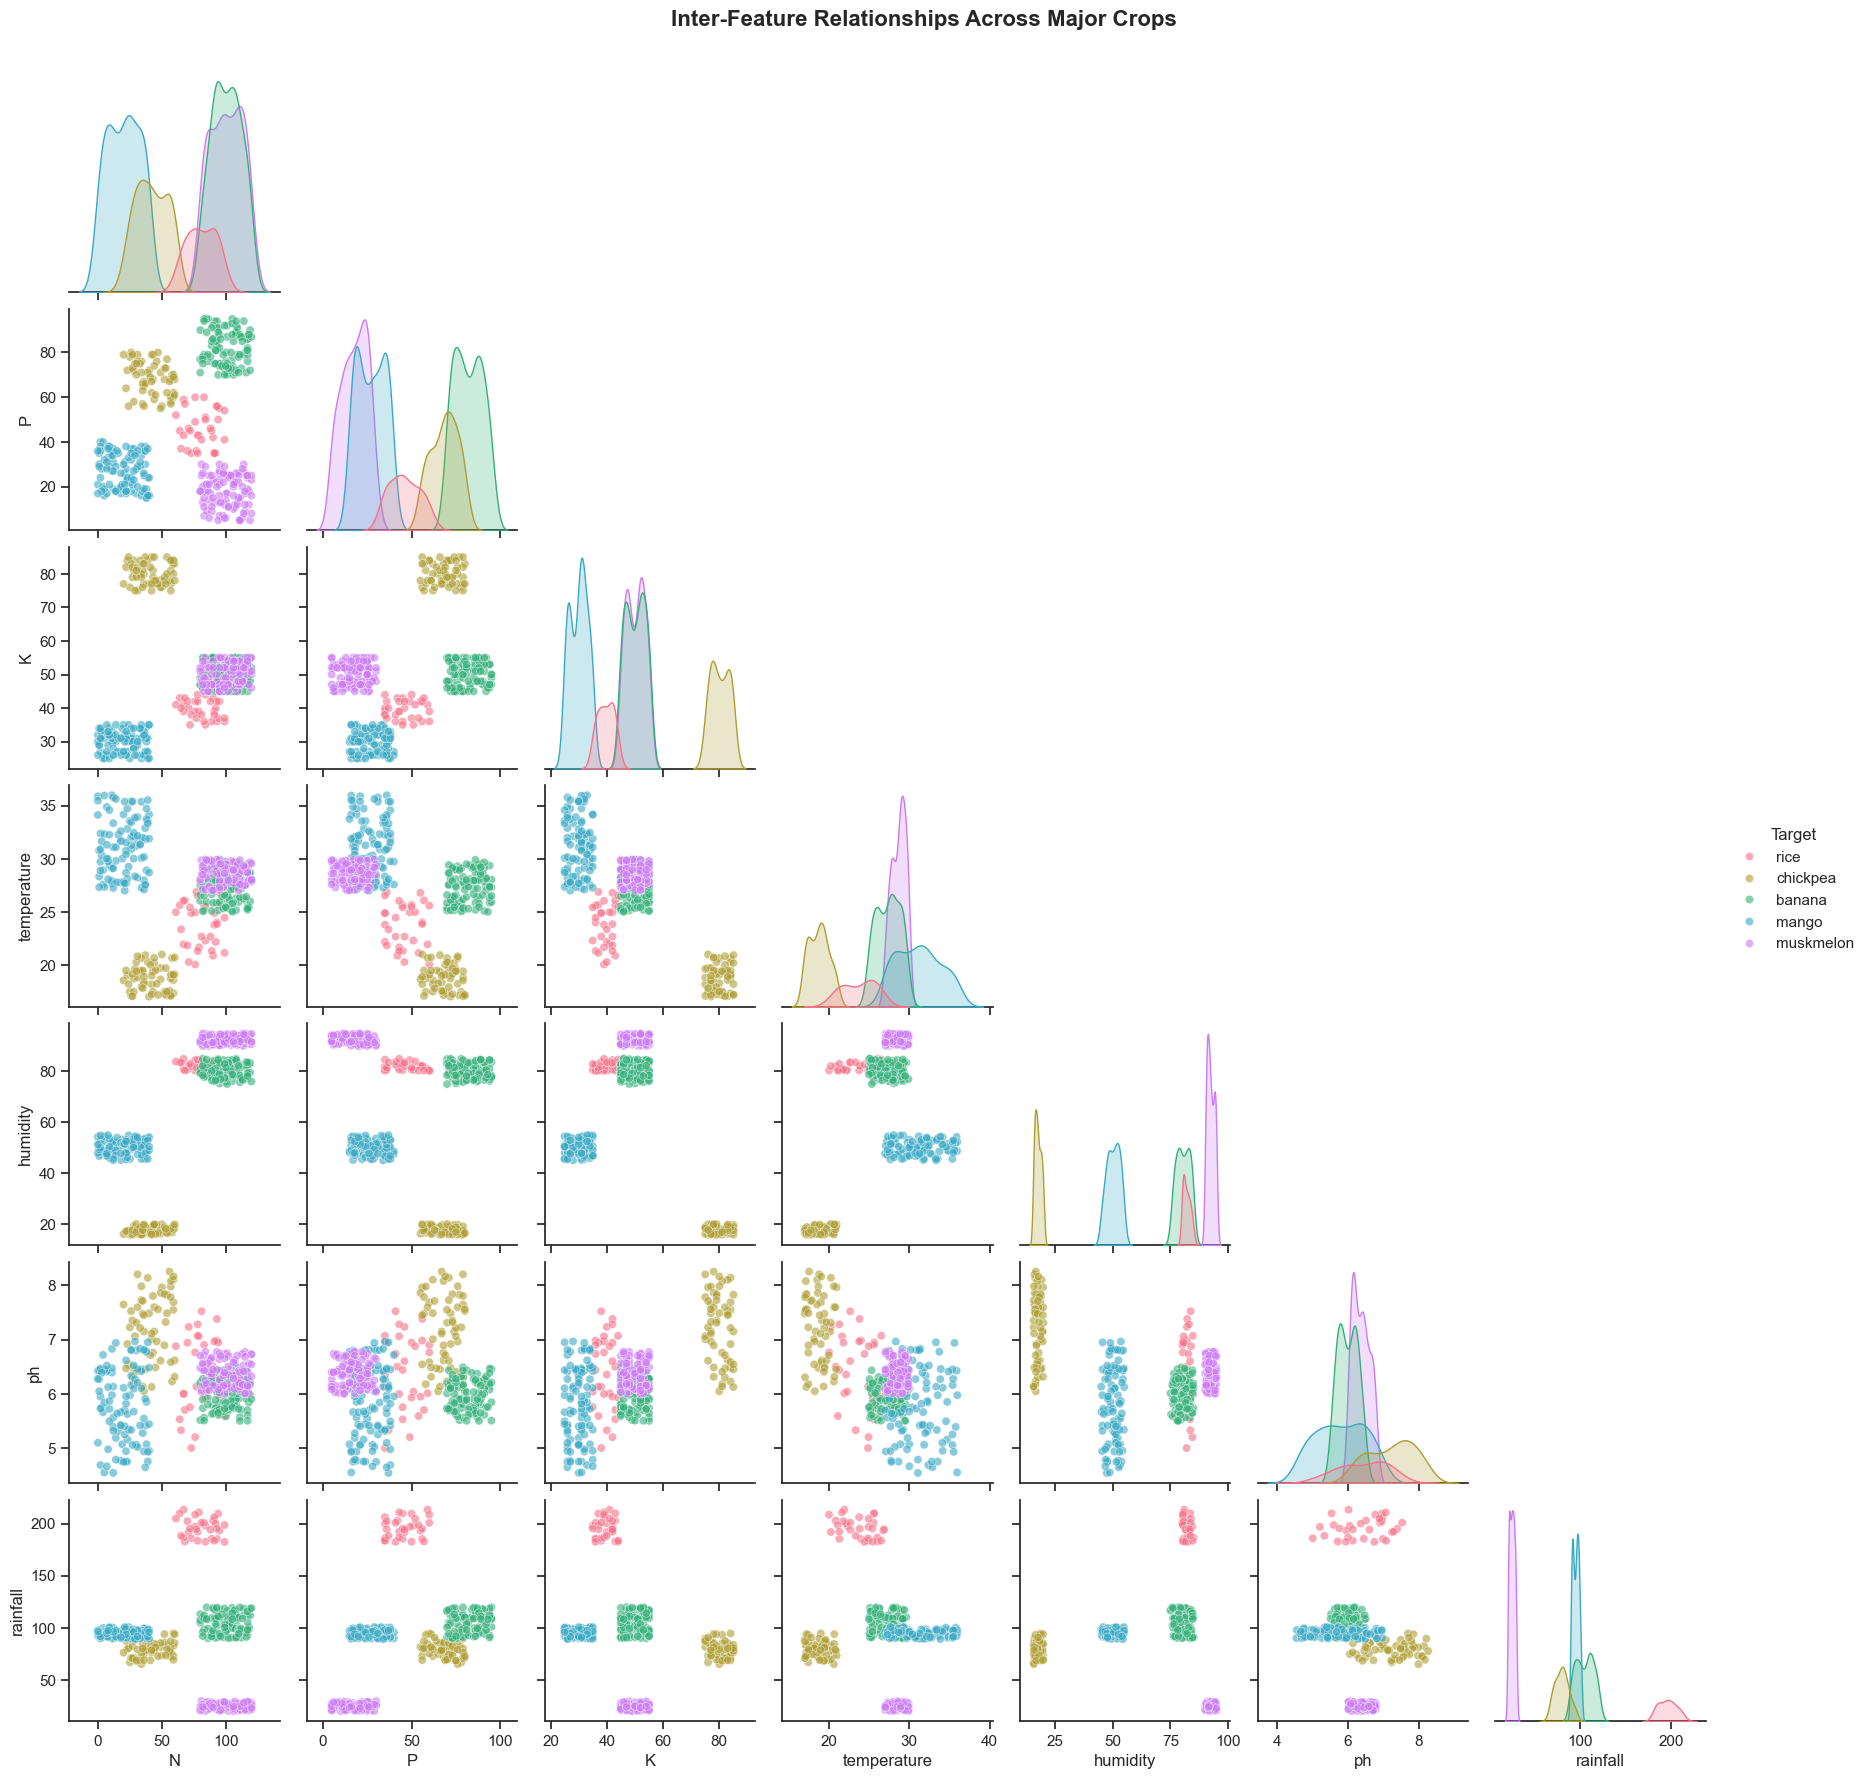

In [11]:
sns.set_theme(style="ticks")
sample_crops = ['rice', 'chickpea', 'banana', 'mango', 'muskmelon']
filtered_df = crop_df[crop_df['Target'].isin(sample_crops)]
print("Generating optimized KDE pairplot... Please wait.")
g = sns.pairplot(
    data=filtered_df,
    hue='Target',
    corner=True,
    palette='husl', 
    plot_kws={'alpha': 0.6}
)
g.fig.suptitle("Inter-Feature Relationships Across Major Crops", y=1.02, fontsize=16, fontweight='bold')
plt.show()

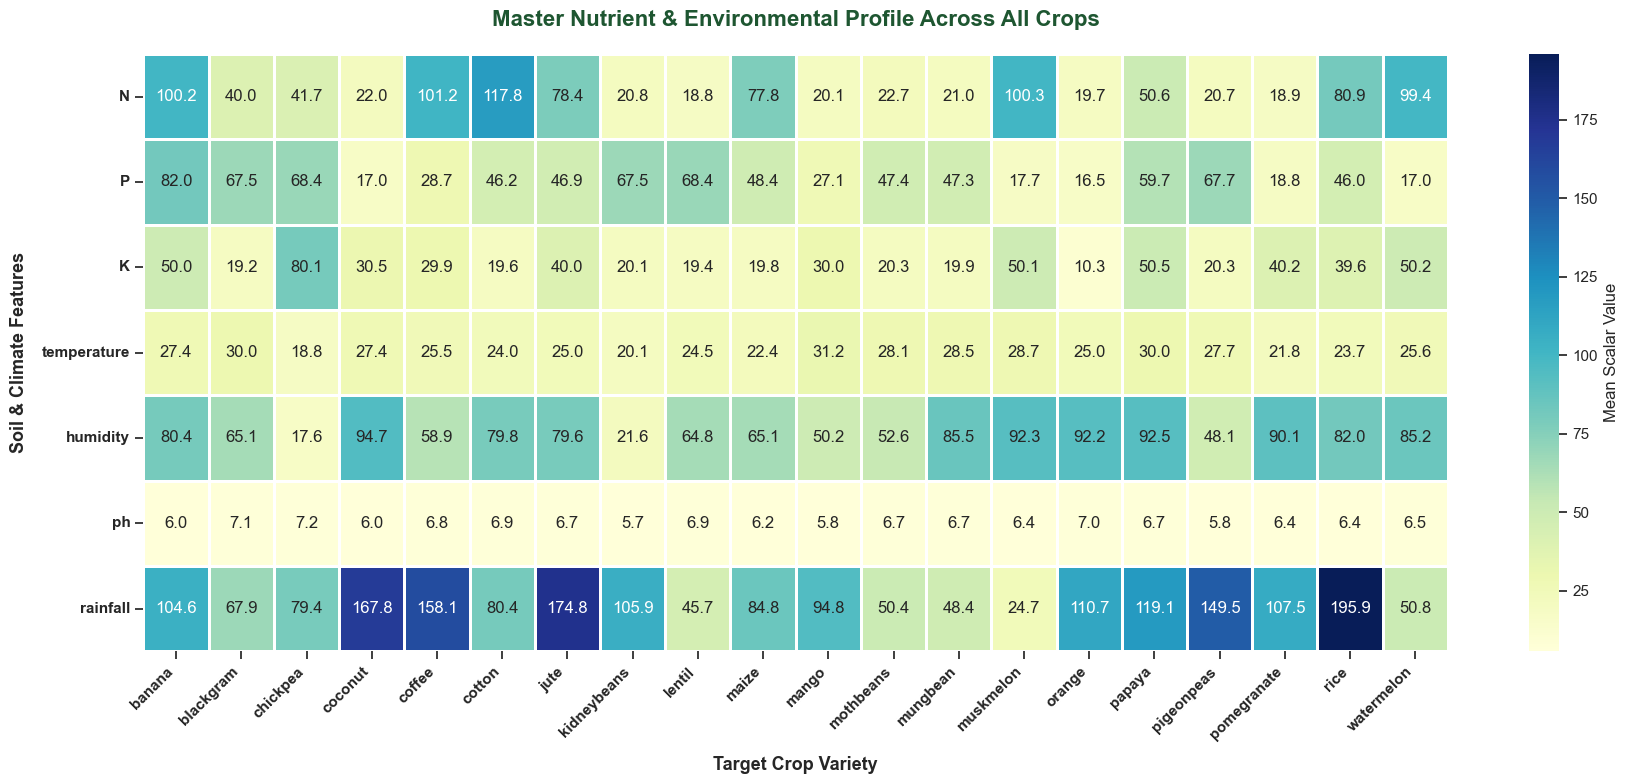

In [12]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
master_matrix = crop_df.groupby('Target')[numeric_cols].mean().T
plt.figure(figsize=(18, 8))
plt.title("Master Nutrient & Environmental Profile Across All Crops", fontsize=16, fontweight='bold', pad=20, color='#1e5631')

sns.heatmap(
    master_matrix, 
    annot=True, 
    cmap='YlGnBu',     
    fmt='.1f', 
    linewidths=0.8,  
    edgecolor='black',
    cbar_kws={'label': 'Mean Scalar Value'} 
)
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.yticks(rotation=0, fontsize=11, fontweight='bold')
plt.xlabel('Target Crop Variety', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Soil & Climate Features', fontsize=13, fontweight='bold', labelpad=10)
plt.tight_layout()
plt.savefig('Master_Crop_Profile_Heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


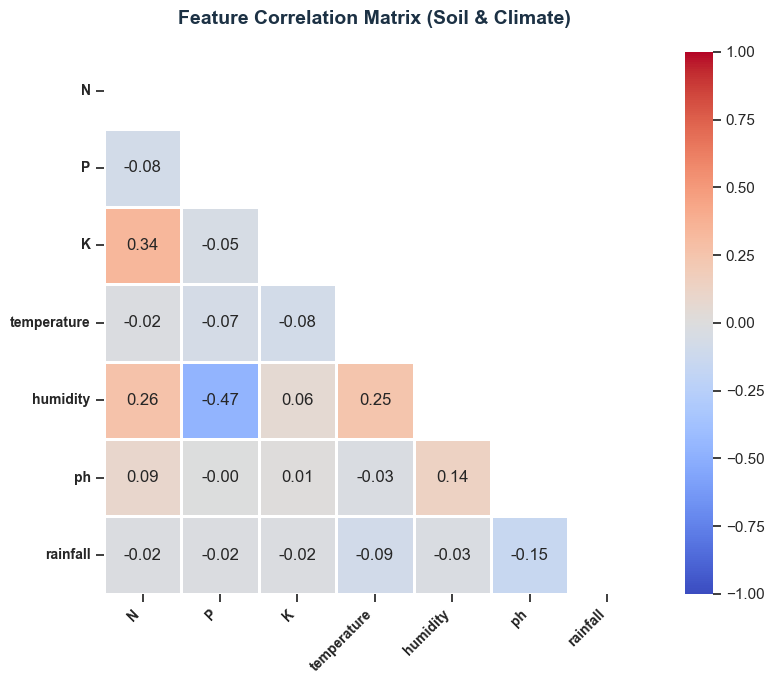

In [13]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr_matrix = crop_df[numeric_cols].corr()
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.title("Feature Correlation Matrix (Soil & Climate)", fontsize=14, fontweight='bold', pad=20, color='#1c3144')
sns.heatmap(
    corr_matrix, 
    mask=mask,          
    annot=True,         
    cmap='coolwarm',    
    fmt='.2f',          
    vmin=-1, vmax=1,    
    linewidths=1,
    edgecolor='white',
    square=True        
)
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('Feature_Correlation_Plot.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


In [14]:
report = ProfileReport(crop_df,explorative = True)
report.to_file(output_file = 'eda_report_crop.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 24.17it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Model Building**

In [15]:
encoder = LabelEncoder()
crop_df['Target_Encoded'] = encoder.fit_transform(crop_df['Target'])

In [16]:
#==========================================================================================================#
# Extract Numerical Features
#==========================================================================================================#
numeric_features = ['temperature', 'ph']
num_transform = ['N', 'P', 'K', 'humidity', 'rainfall']
X = crop_df[numeric_features + num_transform]
y = crop_df['Target_Encoded']

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)

In [18]:
preprocessing_data = ColumnTransformer(transformers=[
    ('num_transform',PowerTransformer(method = 'yeo-johnson'),num_transform),
    ('numeric features',StandardScaler(),numeric_features)
],remainder = 'passthrough')

In [19]:
models = {
    'LogisticRegression' : LogisticRegression(
        max_iter = 1000,
        n_jobs = -1
        
    ),
    'SVC' : SVC(
        C = 1.0,               
        cache_size = 1000,
        gamma = 'scale',
        random_state = 42,
        kernel = 'rbf'         
    ),

    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=4,
        min_samples_split=2,
        max_features='sqrt', 
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoostingClassifier': GradientBoostingClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=4,
        min_samples_split=2,
        random_state=42
    ),
    'XGBClassifier': XGBClassifier(
        n_estimators=300,
        max_depth=15,
        min_child_weight=3,      
        random_state=42,
        n_jobs=-1
    ),
    'LGBMClassifier': LGBMClassifier(
        n_estimators=400,
        max_depth=20,
        n_jobs=-1,
        random_state=42,
        verbose = -1
    )
}


#============================== LogisticRegression ==============================#
Accuracy score Is: 0.9520
Training Accuracy score Is: 0.9689
CV Accuracy (5-fold): 0.9590 (+/- 0.0083)
CV Scores: [0.95053004 0.96466431 0.97173145 0.95759717 0.95035461]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.83      0.95      0.88        20
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      0.80      0.89        20
           7       0.77      1.00      0.87        20
           8       1.00      0.95      0.97        20
           9       0.95      0.90      0.92        20
          10       1.00      1.00      1.00        20
          11       0.92      1.00      0.96        12
          12      

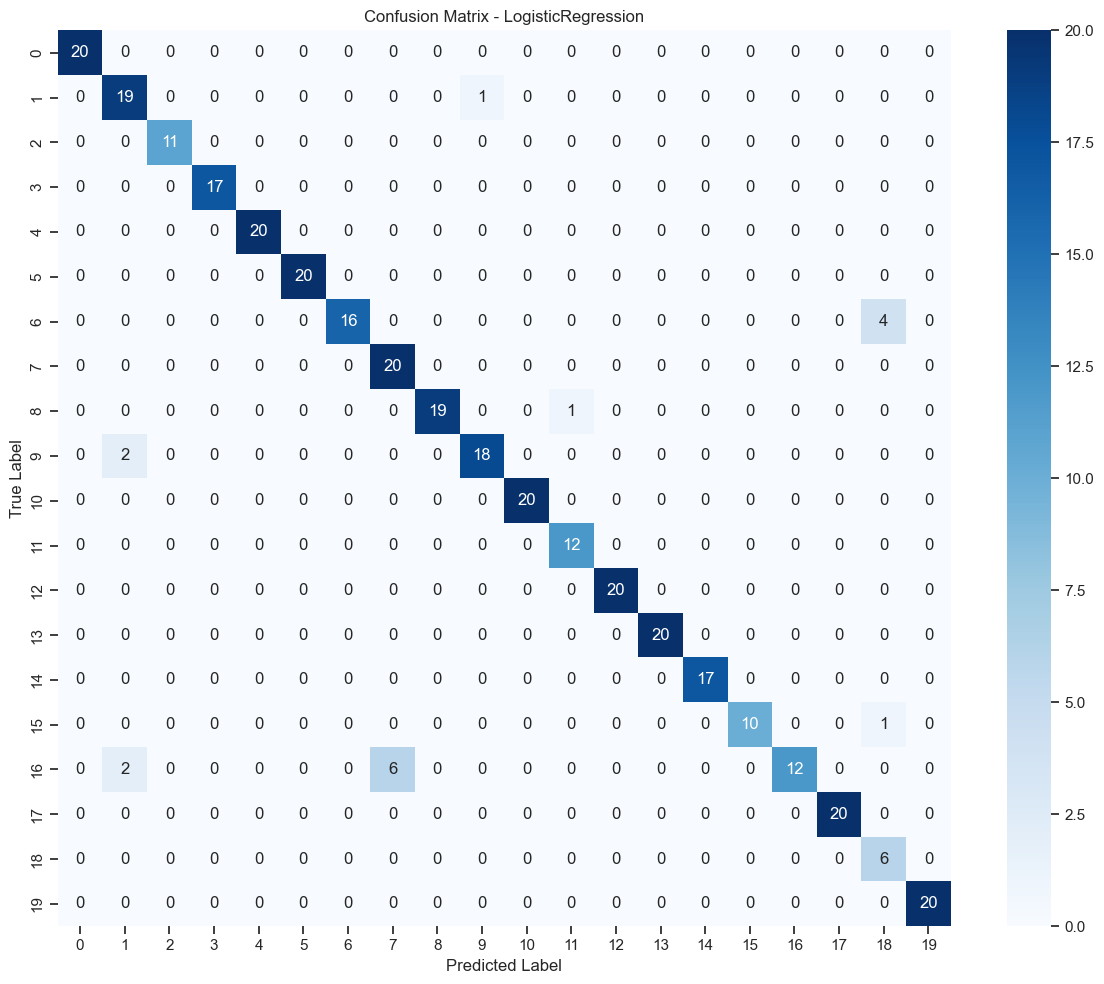

#============================== SVC ==============================#
Accuracy score Is: 0.9605
Training Accuracy score Is: 0.9760
CV Accuracy (5-fold): 0.9653 (+/- 0.0061)
CV Scores: [0.96466431 0.97526502 0.96819788 0.95759717 0.96099291]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      0.65      0.79        20
           7       0.77      1.00      0.87        20
           8       1.00      0.95      0.97        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.92      1.00      0.96        12
          12       1.00      1.00

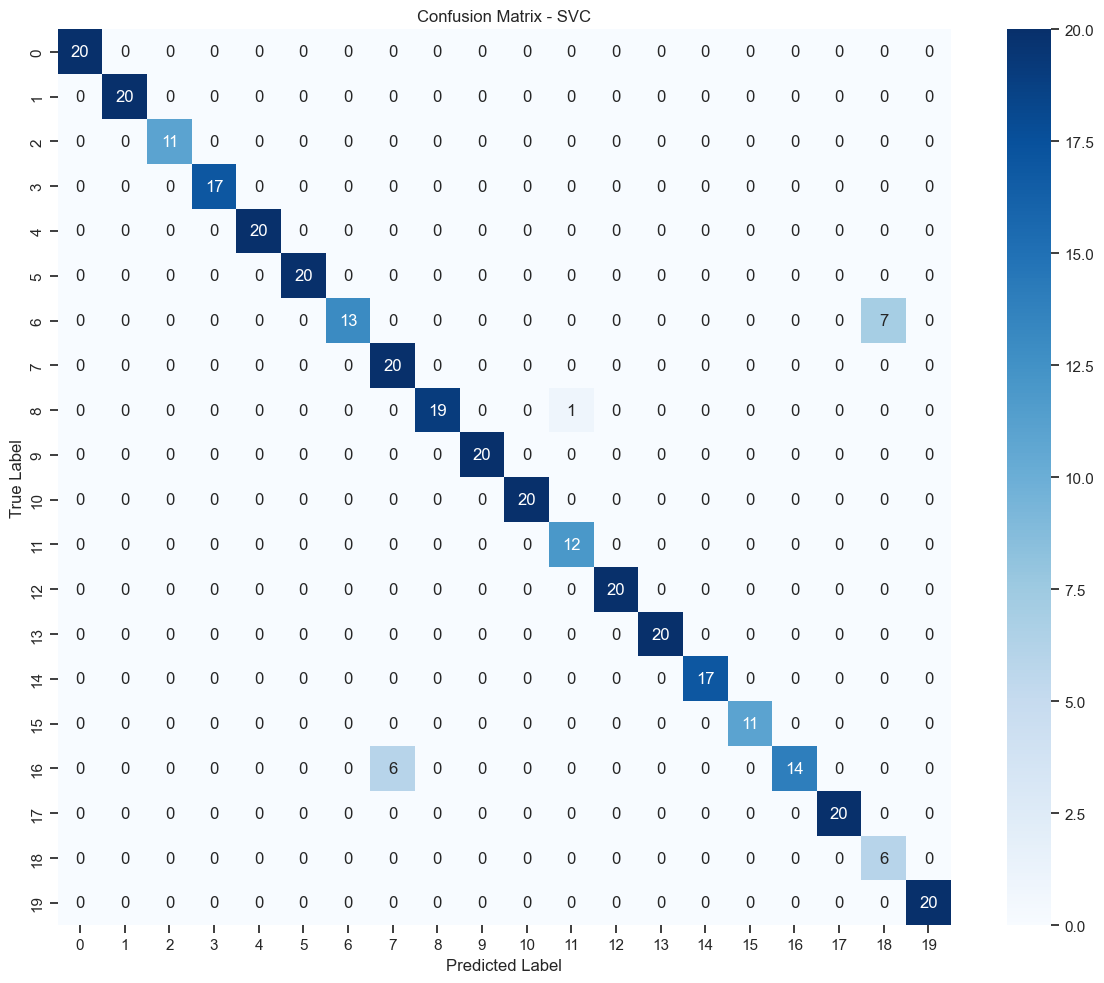

#============================== RandomForestClassifier ==============================#
Accuracy score Is: 0.9944
Training Accuracy score Is: 0.9943
CV Accuracy (5-fold): 0.9873 (+/- 0.0057)
CV Scores: [0.98233216 0.99293286 0.98939929 0.97879859 0.9929078 ]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.95      0.95      0.95        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        12
          12  

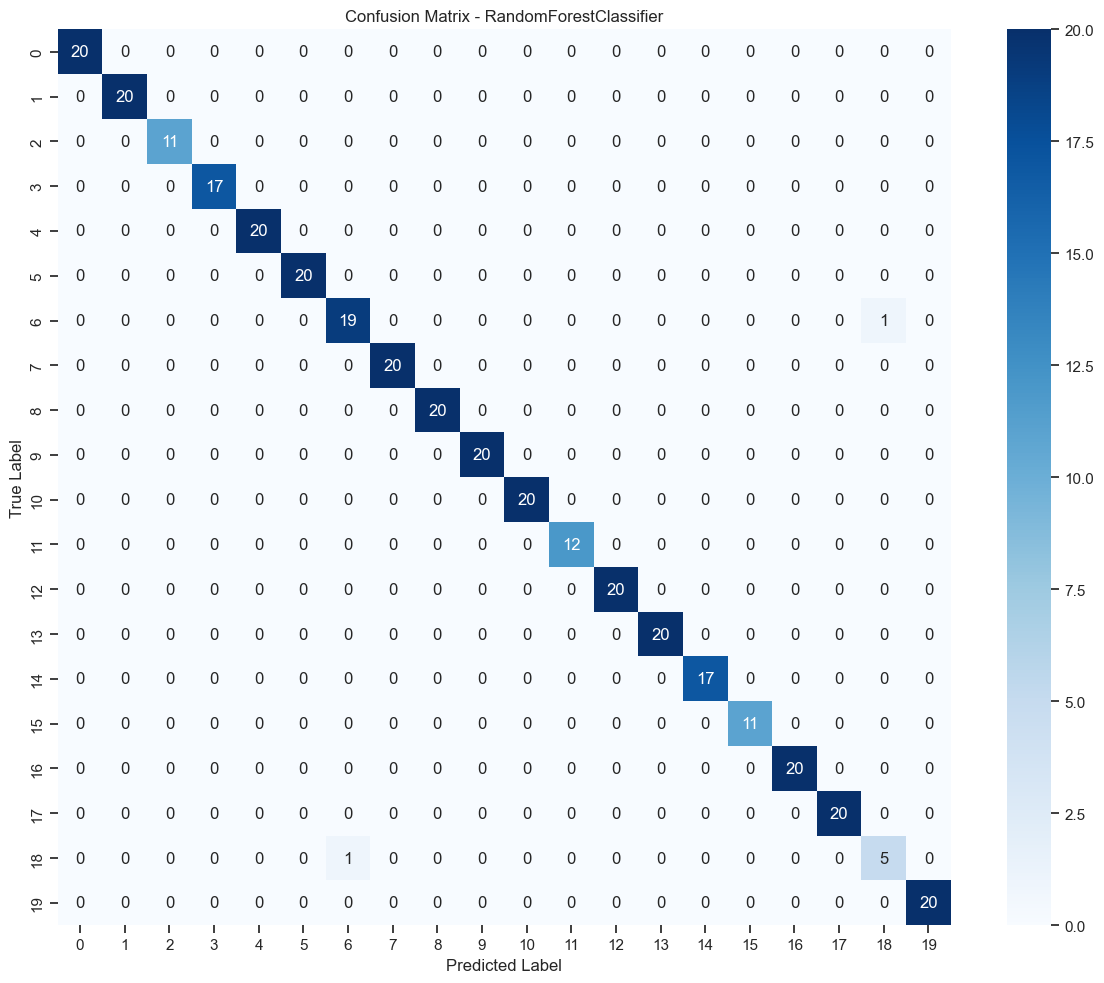

#============================== GradientBoostingClassifier ==============================#
Accuracy score Is: 0.9774
Training Accuracy score Is: 1.0000
CV Accuracy (5-fold): 0.9788 (+/- 0.0107)
CV Scores: [0.96466431 0.98939929 0.97526502 0.97173145 0.9929078 ]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       0.91      1.00      0.95        20
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.95      0.95      0.95        20
           7       1.00      1.00      1.00        20
           8       1.00      0.90      0.95        20
           9       1.00      1.00      1.00        20
          10       1.00      0.90      0.95        20
          11       0.92      0.92      0.92        12
          

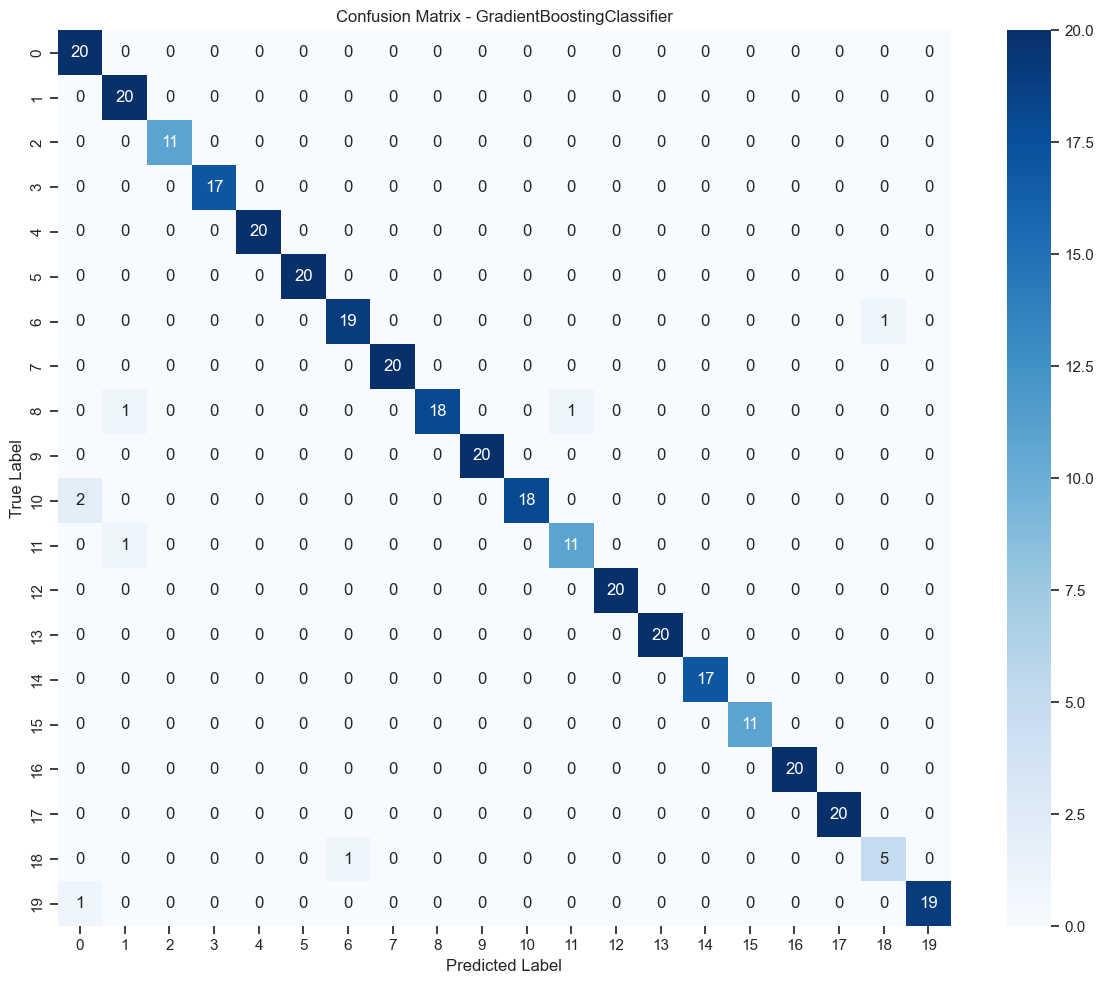

#============================== XGBClassifier ==============================#
Accuracy score Is: 0.9831
Training Accuracy score Is: 1.0000
CV Accuracy (5-fold): 0.9823 (+/- 0.0074)
CV Scores: [0.97526502 0.97879859 0.98939929 0.97526502 0.9929078 ]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.95      1.00      0.98        20
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.95      0.95      0.95        20
           7       0.95      0.95      0.95        20
           8       1.00      0.95      0.97        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.92      0.92      0.92        12
          12       1.00

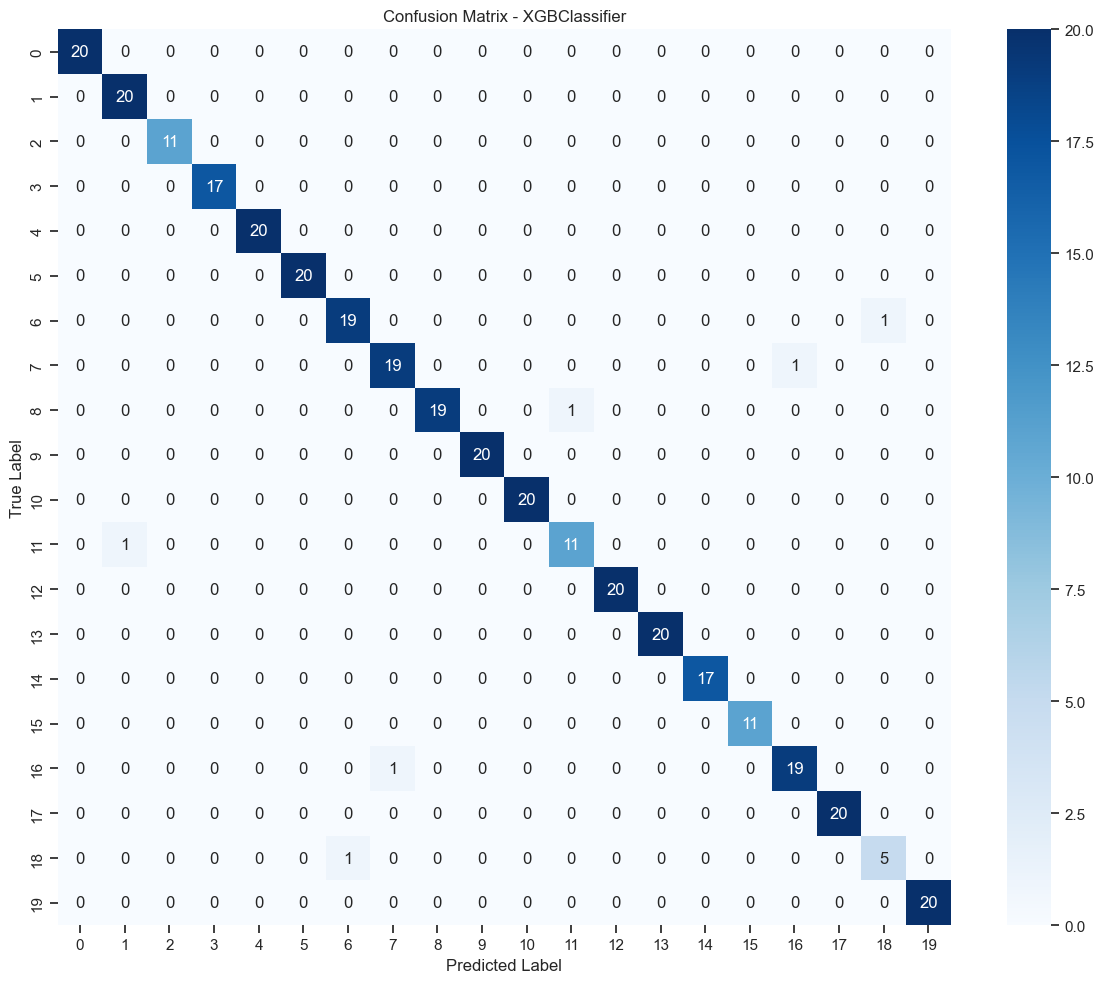

#============================== LGBMClassifier ==============================#
Accuracy score Is: 0.9831
Training Accuracy score Is: 1.0000
CV Accuracy (5-fold): 0.9844 (+/- 0.0057)
CV Scores: [0.97879859 0.99293286 0.98233216 0.97879859 0.9893617 ]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      0.95      0.97        20
           5       1.00      1.00      1.00        20
           6       0.86      0.95      0.90        20
           7       0.95      1.00      0.98        20
           8       1.00      0.95      0.97        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.92      1.00      0.96        12
          12       1.0

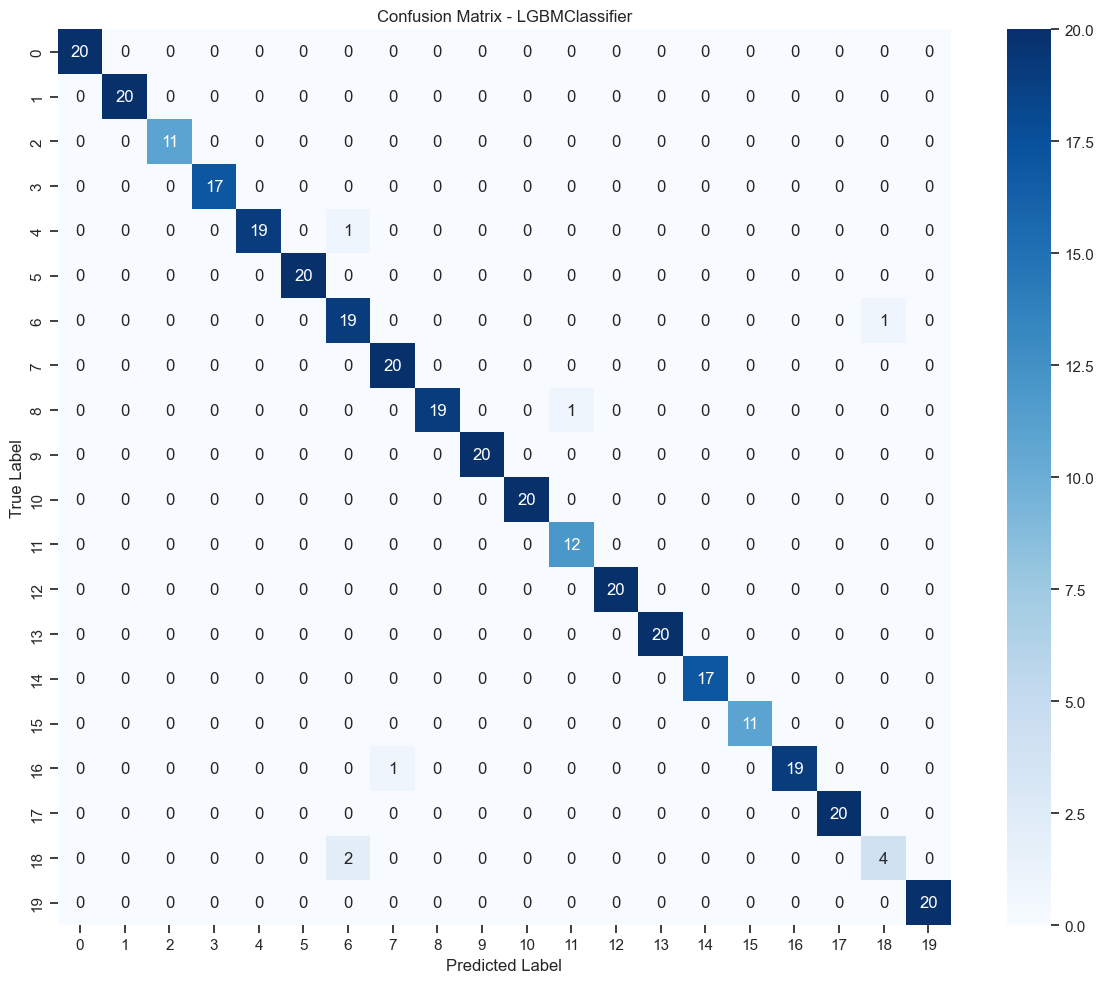

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessing data', preprocessing_data),
        ('SMOTE', SMOTE(random_state=42)),
        ('feature selection', SelectKBest(score_func=f_classif, k=5)),
        (name, model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    print("#" + "=" * 30 + f" {name} " + "=" * 30 + "#")
    print(f"Accuracy score Is: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Training Accuracy score Is: {pipeline.score(X_train, y_train):.4f}")
    print(f"CV Accuracy (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"CV Scores: {cv_scores}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_test.unique()) if hasattr(y_test, 'unique') else range(cm.shape[0]),
                yticklabels=sorted(y_test.unique()) if hasattr(y_test, 'unique') else range(cm.shape[0]))
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# **Hpyer Parameter Tunning**

In [21]:
rf_tunning = Pipeline(steps = [
    ('preprocessing data', preprocessing_data),
    ('SMOTE', SMOTE(random_state = 42)),
    ('feature selection', SelectKBest(score_func = f_classif, k = 5)),
    ('rf', RandomForestClassifier(random_state = 42))
])
param_grid = {
    'rf__n_estimators':[100,200,300,400,500],
    'rf__max_depth':[10,15,20,25,30],
    'rf__min_samples_leaf': [2,4,6,8],
    'rf__min_samples_split':[2,4,6],
    'rf__max_features': ['sqrt', 'log2']
}
random_search = RandomizedSearchCV(
    estimator = rf_tunning,
    param_distributions = param_grid,
    cv = 5,
    scoring = 'precision_macro',
    random_state = 42,
    n_iter = 10
)
random_search.fit(X_train, y_train)

print(f"best cv score: {random_search.best_score_}")
print(f"Best cv parameters: {random_search.best_params_}")

best_model_rf = random_search.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

print(f"Training score: {best_model_rf.score(X_train, y_train)}")
print(f"Accuracy score: {accuracy_score(y_test, y_pred_rf)}") 
print(classification_report(y_test, y_pred_rf))

best cv score: 0.9832521008403361
Best cv parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 15}
Training score: 0.9978783592644979
Accuracy score: 0.9971751412429378
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      0.95      0.97        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00

In [27]:
#==============================================================================================================#
# Save The model
#==============================================================================================================#
joblib.dump(best_model_rf, 'crop_best_rf_model.pkl')
joblib.dump(encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [23]:
feature_names = best_model_rf.named_steps['preprocessing data'].get_feature_names_out()
mask = best_model_rf.named_steps['feature selection'].get_support()
selected_features = feature_names[mask]
print(selected_features)

['num_transform__N' 'num_transform__P' 'num_transform__K'
 'num_transform__humidity' 'num_transform__rainfall']


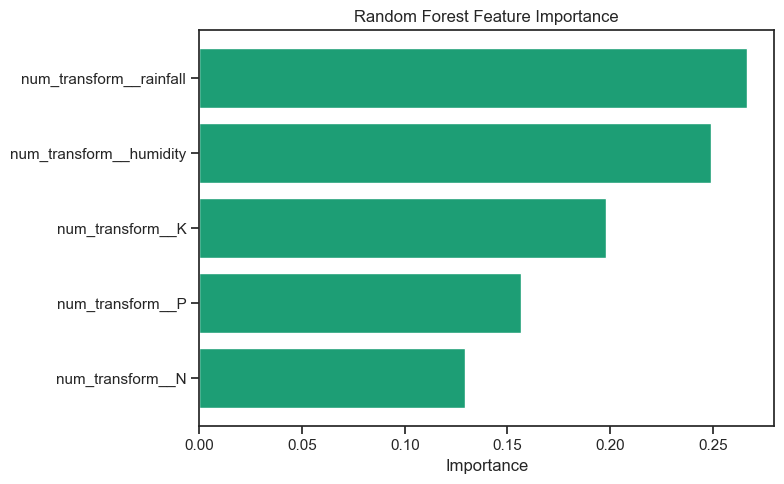

In [26]:
feature_names = best_model_rf.named_steps['preprocessing data'].get_feature_names_out()
mask = best_model_rf.named_steps['feature selection'].get_support()
selected_features = feature_names[mask]
importances = best_model_rf.named_steps['rf'].feature_importances_
sorted_idx = np.argsort(importances)
sorted_features = selected_features[sorted_idx]
sorted_importances = importances[sorted_idx]
plt.figure(figsize=(8,5))
plt.barh(sorted_features, sorted_importances, color='#1D9E75')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()